# ML predictions for Pt doped dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Data preparation (before data addition)

In [40]:
# Loading data
data_full = pd.read_csv('../Datasets/Pt_data.csv')
data = data_full.iloc[0:57]
data = data.iloc[:, 1:]

In [41]:
# 1. Select only columns corresponding to selected features
# N used for splitting; removed later

selected_features = ['E_formation','N','CN_4Å_mean', 'q_Ti_min', 'E_vacuum_dopant_face', 'Ti_dopant_Ti_angle_std']
data = data[selected_features]

In [42]:
# 2. Unique configurations N = 1, 29, or 30 into the test set
extreme_data = data["N"].isin([1, 29, 30])
extreme_set = data[extreme_data]
remaining_data = data[~extreme_data]

In [43]:
# 3. Split remaining data into training and test sets
random_set, train_set = train_test_split(
    remaining_data,
    test_size=0.8,   # keep 80% for training
    random_state=42
)

In [44]:
# 4. Complete test set
test_set = pd.concat([extreme_set, random_set], axis=0)

In [51]:
# 5. Finally, drop N
F_train = train_set.drop(columns=['N'])
F_test  = test_set.drop(columns=['N'])

## Predictions (before data addition)

In [46]:
# Variables
X = F_train.drop(columns=["E_formation"])
y = F_train["E_formation"]

X_test = F_test.drop(columns=["E_formation"])
y_test = F_test["E_formation"]

# Kernel defined
kernel = (
    C(1.0, (1e-2, 1e2))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e10))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e2))
)

# Models
model_dict = {
    "LR": LinearRegression(),
    "LASSO": Lasso(),
    "RLR": Ridge(),
    "EN": ElasticNet(),
    "RF": RandomForestRegressor(random_state=42),
    "GBR": GradientBoostingRegressor(random_state=42),
    "kNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "GPR": GaussianProcessRegressor(kernel=kernel, normalize_y=True)
}

# Hyperparameter grids
param_grids = {
    "LR": {},

    "LASSO": {"model__alpha": [0.001, 0.01, 0.1, 1]},

    "RLR": {"model__alpha": [0.001, 0.01, 0.1, 1]},

    "EN": {
        "model__alpha": [0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.1, 0.5, 0.9]},

    "RF": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5]},

    "GBR": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [2, 3, 5]},

    "kNN": {
        "model__n_neighbors": [2, 3, 5, 7],
        "model__weights": ["uniform", "distance"]},

    "SVR": {
        "model__C": [1, 10, 50, 100],
        "model__epsilon": [0.01, 0.05, 0.1],
        "model__gamma": ["scale", 0.01, 0.001]},

    "GPR": {
        "model__alpha": [1e-8, 1e-5, 1e-3]}
}


# ----------------------------------------------------------------------
# Hyperparameter optimization + Cross-validation (CD) + Model evaluation

results = {}
best_models = {}
predictions = {}

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

for name, model in model_dict.items():
    #print(f"\nTuning {name} ...")

    if name in ["SVR", "kNN", "GPR"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipe = Pipeline([("model", model)])

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring=scoring,
        refit="r2",      
        cv=5,
        n_jobs=-1,
        return_train_score=True
    )

    gs.fit(X, y)

    best_models[name] = gs.best_estimator_

    # CV metrics
    cv_r2 = gs.cv_results_["mean_test_r2"][gs.best_index_]
    cv_rmse = -gs.cv_results_["mean_test_rmse"][gs.best_index_]
    cv_mae = -gs.cv_results_["mean_test_mae"][gs.best_index_]

    # Train and test metrics
    y_train_pred = gs.predict(X)
    y_test_pred  = gs.predict(X_test)

    train_r2 = r2_score(y, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_pred)

    results[name] = {
        "Training R2": train_r2,
        "CV R2": cv_r2,
        "CV RMSE": cv_rmse,
        "CV MAE": cv_mae,
        "Test R2": test_r2,
        "Test RMSE": rmse,
        "Test MAE": mae,
    }
    predictions[name] = y_test_pred

# Table for results
results_df = pd.DataFrame(results).T
results_df

,Training R2,CV R2,CV RMSE,CV MAE,Test R2,Test RMSE,Test MAE
LR,0.970811,0.951839,0.018094,0.013884,0.840171,0.037683,0.028229
LASSO,0.948313,0.922567,0.022244,0.016440,0.750298,0.047101,0.028350
RLR,0.970743,0.952986,0.017886,0.013701,0.837112,0.038042,0.028249
EN,0.969020,0.953527,0.017677,0.013446,0.825092,0.039420,0.027817
RF,0.992985,0.939555,0.020528,0.017419,0.800506,0.042100,0.026975
GBR,0.999987,0.943777,0.019889,0.016967,0.829562,0.038913,0.026638
kNN,1.000000,0.931933,0.021667,0.017743,0.825178,0.039411,0.024333
SVR,0.985417,0.969500,0.014257,0.011952,0.911103,0.028103,0.016714
GPR,0.986309,0.970691,0.013802,0.011170,0.904807,0.029082,0.018886


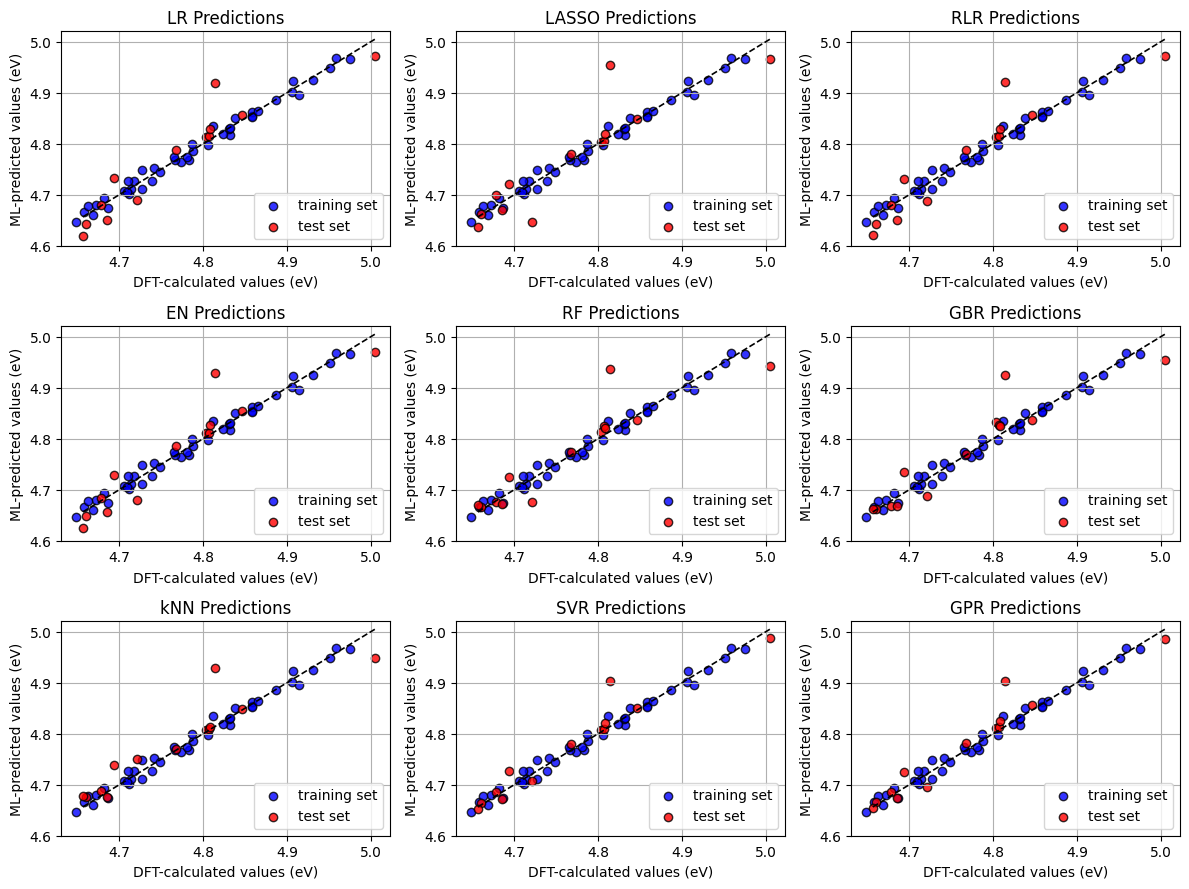

In [47]:
# Scatter plots: calculated vs. predicted values
fig, axes = plt.subplots(3, 3, figsize=(12,9))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    # train (blue) and test (red)
    ax.scatter(y, y_train_pred, alpha=0.8, color="blue", edgecolors="black")
    ax.scatter(y_test, y_pred, alpha=0.8, color="red", edgecolors="black")
    #perfect prediction
    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "--", color="black", linewidth=1.2)
    ax.set_title(f"{name} Predictions")
    ax.set_xlabel("DFT-calculated values (eV)")
    ax.set_ylabel("ML-predicted values (eV)")
    ax.set_ylim(4.6,5.02)
    ax.set_xticks([4.7, 4.8, 4.9, 5.0])
    ax.set_xticklabels(["4.7", "4.8", "4.9", "5.0"])
    ax.grid(True)
    ax.legend(['training set', 'test set'],loc='lower right')
plt.tight_layout()
plt.show()

# Data preparation (after data addition)

In [49]:
# Load additional data
data_extended = data_full.iloc[57:84]
data_extended = data_extended.iloc[:, 1:]

selected_features = ['E_formation','N','CN_4Å_mean', 'q_Ti_min', 'E_vacuum_dopant_face', 'Ti_dopant_Ti_angle_std']
data_extended = data_extended[selected_features]

In [50]:
# Extended training set
extended_train_set = pd.concat([train_set, data_extended], axis=0).reset_index(drop=True)

In [53]:
# Again, drop N 
extended_train = extended_train_set.drop(columns=['N'])

In [55]:
# Variables
Xa = extended_train.drop(columns=["E_formation"])
ya = extended_train["E_formation"]

Xa_test = F_test.drop(columns=["E_formation"])
ya_test = F_test["E_formation"]

# Kernel defined
kernel = (
    C(1.0, (1e-2, 1e2))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e10))
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e2))
)

# Models
model_dict = {
    "LR": LinearRegression(),
    "LASSO": Lasso(),
    "RLR": Ridge(),
    "EN": ElasticNet(),
    "RF": RandomForestRegressor(random_state=42),
    "GBR": GradientBoostingRegressor(random_state=42),
    "kNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "GPR": GaussianProcessRegressor(kernel=kernel, normalize_y=True)
}

# Hyperparameter grids
param_grids = {
    "LR": {},

    "LASSO": {"model__alpha": [0.001, 0.01, 0.1, 1]},

    "RLR": {"model__alpha": [0.001, 0.01, 0.1, 1]},

    "EN": {
        "model__alpha": [0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.1, 0.5, 0.9]},

    "RF": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5]},

    "GBR": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [2, 3, 5]},

    "kNN": {
        "model__n_neighbors": [2, 3, 5, 7],
        "model__weights": ["uniform", "distance"]},

    "SVR": {
        "model__C": [1, 10, 50, 100],
        "model__epsilon": [0.01, 0.05, 0.1],
        "model__gamma": ["scale", 0.01, 0.001]},

    "GPR": {
        "model__alpha": [1e-8, 1e-5, 1e-3]}
}


# ----------------------------------------------------------------------
# Hyperparameter optimization + Cross-validation (CD) + Model evaluation

results = {}
best_models = {}
predictions = {}

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

for name, model in model_dict.items():
    #print(f"\nTuning {name} ...")

    if name in ["SVR", "kNN", "GPR"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipe = Pipeline([("model", model)])

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring=scoring,
        refit="r2",      
        cv=5,
        n_jobs=-1,
        return_train_score=True
    )

    gs.fit(Xa, ya)

    best_models[name] = gs.best_estimator_

    # CV metrics
    cv_r2 = gs.cv_results_["mean_test_r2"][gs.best_index_]
    cv_rmse = -gs.cv_results_["mean_test_rmse"][gs.best_index_]
    cv_mae = -gs.cv_results_["mean_test_mae"][gs.best_index_]

    # Train and test metrics
    y_train_pred = gs.predict(Xa)
    y_test_pred  = gs.predict(Xa_test)

    train_r2 = r2_score(ya, y_train_pred)
    test_r2  = r2_score(ya_test, y_test_pred)
    mse = mean_squared_error(ya_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(ya_test, y_test_pred)

    results[name] = {
        "Training R2": train_r2,
        "CV R2": cv_r2,
        "CV RMSE": cv_rmse,
        "CV MAE": cv_mae,
        "Test R2": test_r2,
        "Test RMSE": rmse,
        "Test MAE": mae,
    }
    predictions[name] = y_test_pred

# Table for results
results_df = pd.DataFrame(results).T
results_df

,Training R2,CV R2,CV RMSE,CV MAE,Test R2,Test RMSE,Test MAE
LR,0.949693,0.852359,0.023309,0.016175,0.803648,0.041767,0.029046
LASSO,0.938071,0.859763,0.025289,0.018478,0.748739,0.047247,0.029181
RLR,0.949159,0.869379,0.022918,0.016367,0.794304,0.042749,0.028874
EN,0.946043,0.869280,0.023608,0.017105,0.777518,0.044459,0.028520
RF,0.990778,0.856728,0.025170,0.019330,0.875050,0.033318,0.021069
GBR,0.996031,0.874680,0.023231,0.018032,0.871488,0.033790,0.022286
kNN,1.000000,0.731582,0.028888,0.018496,0.863441,0.034832,0.022103
SVR,0.979259,0.901914,0.018978,0.014103,0.919113,0.026807,0.018188
GPR,0.981348,0.903377,0.019246,0.014516,0.901327,0.029608,0.020571


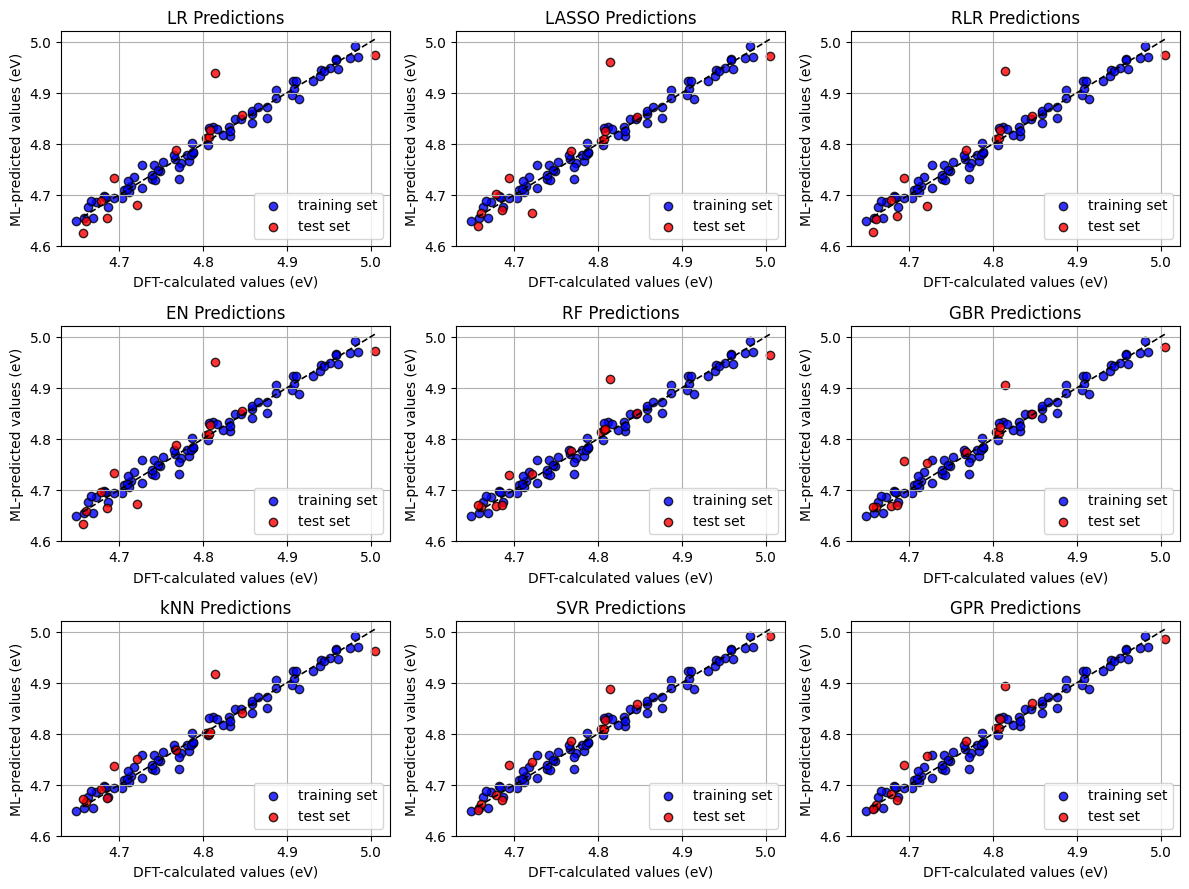

In [57]:
# Scatter Plots: Actual vs. Predicted Values
fig, axes = plt.subplots(3, 3, figsize=(12,9))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.scatter(ya, y_train_pred, alpha=0.8, color="blue", edgecolors="black")
    ax.scatter(ya_test, y_pred, alpha=0.8, color="red", edgecolors="black")
    ax.plot([min(ya_test), max(ya_test)], [min(ya_test), max(ya_test)], "--", color="black", linewidth=1.2)
    ax.set_title(f"{name} Predictions")
    ax.set_xlabel("DFT-calculated values (eV)")
    ax.set_ylabel("ML-predicted values (eV)")
    ax.set_ylim(4.6,5.02)
    ax.set_xticks([4.7, 4.8, 4.9, 5.0])
    ax.set_xticklabels(["4.7", "4.8", "4.9", "5.0"])
    ax.grid(True)
    ax.legend(['training set', 'test set'],loc='lower right')
plt.tight_layout()
plt.show()